In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df= pd.read_csv('diabetic_data.csv')

In [8]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [10]:
df.shape

(101766, 50)

In [11]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [12]:
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [13]:
df.replace('?', np.nan, inplace=True)
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [14]:
df.duplicated().sum()

np.int64(0)

<div align="center">

# 🩺 Diabetes Readmission Prediction System  
### *From Data Analysis to Machine Learning Deployment*

<img src="https://img.shields.io/badge/Dataset-101K%20Patients-blue?style=for-the-badge">
<img src="https://img.shields.io/badge/Focus-Healthcare%20AI-success?style=for-the-badge">
<img src="https://img.shields.io/badge/Project-ML%20%26%20Deployment-orange?style=for-the-badge">

</div>

---

# 📌 Project Overview

Hospital readmission is one of the most significant challenges in healthcare systems, especially for diabetic patients. Early prediction of patient readmission can help hospitals improve treatment quality, reduce healthcare costs, and enhance patient outcomes.

This project focuses on building a complete **Machine Learning pipeline** using a real-world healthcare dataset containing **over 100,000 diabetic patient records**.

The dataset includes:

- 👨‍⚕️ Patient demographic information  
- 🏥 Hospital admission details  
- 💊 Diabetes medications  
- 🧪 Laboratory test results  
- 📋 Diagnoses and medical history  
- 🔁 Readmission status  

---

# 🎯 Project Objectives

✔️ Perform comprehensive data cleaning and preprocessing  

✔️ Handle missing and inconsistent medical data  

✔️ Conduct Exploratory Data Analysis (EDA) and visualization  

✔️ Detect and analyze outliers  

✔️ Apply feature encoding and transformation techniques  

✔️ Build Machine Learning models to predict patient readmission  

✔️ Evaluate model performance using suitable metrics  

✔️ Deploy the final model for real-world usage  

---

# 🤖 Machine Learning Goal

The primary goal of this project is to predict whether
a diabetic patient is likely to be readmitted to the hospital based on medical history,
#treatments, and hospital records.

This prediction system can help healthcare providers:
- Improve patient monitoring  
- Reduce avoidable readmissions  
- Support medical decision-making  
- Enhance healthcare efficiency  

---

# 📊 Why This Project Matters

Healthcare analytics and AI are transforming the medical field by enabling data-driven decisions and predictive healthcare systems.

By combining data analysis, machine learning, and deployment, this project demonstrates how artificial intelligence can contribute to smarter and more efficient healthcare solutions.

---

<div align="center">

## 🚀 Tools & Technologies

`Python` • `Pandas` • `NumPy` • `Matplotlib` • `Seaborn` • `Scikit-learn`

</div>

In [15]:
# Drop duplicate patients to prevent data leakage
df.drop_duplicates(subset=['patient_nbr'], keep='first', inplace=True)
df.drop(columns=['encounter_id', 'patient_nbr', 'weight', 'payer_code'], inplace=True)

In [16]:
df['race'] = df['race'].fillna(df['race'].mode()[0])

In [17]:
# Fill missing medical_specialty with 'Unknown' instead of ffill
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

In [18]:
# Fill missing lab results with 'None' instead of ffill
df[['max_glu_serum', 'A1Cresult']] = df[['max_glu_serum', 'A1Cresult']].fillna('None')

In [19]:
import math
def categorize_diagnosis(code):
    if code == 'Unknown' or pd.isna(code) or code == '?':
        return 'Unknown'
    try:
        if code.startswith('V') or code.startswith('E'):
            return 'External/Supplemental'
        
        num_code = float(code)
        if 390 <= num_code <= 459 or num_code == 785:
            return 'Circulatory'
        elif 460 <= num_code <= 519 or num_code == 786:
            return 'Respiratory'
        elif 520 <= num_code <= 579 or num_code == 787:
            return 'Digestive'
        elif math.floor(num_code) == 250:
            return 'Diabetes'
        elif 800 <= num_code <= 999:
            return 'Injury'
        elif 710 <= num_code <= 739:
            return 'Musculoskeletal'
        elif 580 <= num_code <= 629 or num_code == 788:
            return 'Genitourinary'
        elif 140 <= num_code <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

df[['diag_1', 'diag_2', 'diag_3']] = df[['diag_1', 'diag_2', 'diag_3']].fillna('Unknown')
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(categorize_diagnosis)

In [20]:
# ── Feature Engineering ─────────────────────────────────────────────────
# Count how many diabetes medications were changed (Up or Down) during the visit.
# A patient with many medication changes is clinically unstable — a strong readmission signal.
_med_cols_raw = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
                 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
                 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
                 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
                 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
existing_med_cols = [c for c in _med_cols_raw if c in df.columns]
df['num_meds_changed'] = df[existing_med_cols].apply(
    lambda row: row.isin(['Up', 'Down']).sum(), axis=1
)

# Aggregate prior visit history into a single high-signal feature.
df['total_prior_visits'] = (
    df['number_outpatient'].fillna(0)
    + df['number_emergency'].fillna(0)
    + df['number_inpatient'].fillna(0)
)

# Binary flag for discharge dispositions associated with high readmission risk
# (e.g. transferred to skilled nursing, rehab, or discharged against medical advice).
_high_risk_ids = {2, 3, 4, 5, 6, 8, 15, 22, 23, 24, 25, 26, 27, 28, 29, 30}
df['high_risk_discharge'] = df['discharge_disposition_id'].isin(_high_risk_ids).astype(int)
print('Feature engineering complete.')
print(f'  num_meds_changed   — mean: {df["num_meds_changed"].mean():.2f}')
print(f'  total_prior_visits — mean: {df["total_prior_visits"].mean():.2f}')
print(f'  high_risk_discharge — pct: {df["high_risk_discharge"].mean()*100:.1f}%')

Feature engineering complete.
  num_meds_changed   — mean: 0.26
  total_prior_visits — mean: 0.56
  high_risk_discharge — pct: 31.8%


In [21]:
df.isna().sum()

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 71518 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   race                      71518 non-null  str  
 1   gender                    71518 non-null  str  
 2   age                       71518 non-null  str  
 3   admission_type_id         71518 non-null  int64
 4   discharge_disposition_id  71518 non-null  int64
 5   admission_source_id       71518 non-null  int64
 6   time_in_hospital          71518 non-null  int64
 7   medical_specialty         71518 non-null  str  
 8   num_lab_procedures        71518 non-null  int64
 9   num_procedures            71518 non-null  int64
 10  num_medications           71518 non-null  int64
 11  number_outpatient         71518 non-null  int64
 12  number_emergency          71518 non-null  int64
 13  number_inpatient          71518 non-null  int64
 14  diag_1                    71518 non-null  str  
 15  

# 🧹 Data Cleaning & Preprocessing

Data cleaning is one of the most critical stages in any data science project because the quality of the dataset directly impacts the accuracy, reliability, and performance of machine learning models.

The healthcare dataset used in this project contained missing values, inconsistent entries, high-cardinality categorical features, and unnecessary columns that required preprocessing before proceeding to machine learning modeling and deployment.

---

# 📌 Data Cleaning Process

## 1️⃣ Handling Missing Values

The dataset contained missing values across multiple columns. Different preprocessing techniques were applied depending on the nature and importance of each feature.

Some missing values were initially represented using special symbols instead of standard null values, so they were first converted into proper missing values for consistency and easier processing.

---

## 2️⃣ Removing Unnecessary Features

Several features were removed because they do not contribute meaningful information for predicting patient readmission.

### Removed Features:
- encounter_id
- patient_nbr
- weight
- payer_code

### Reasons:
- encounter_id and patient_nbr are unique identifiers and provide no predictive medical value.
- weight contained an extremely high percentage of missing values.
- payer_code represents financial and insurance-related information rather than patient health conditions.

Removing irrelevant columns helps reduce noise, simplify the dataset, and improve overall model efficiency.

---

## 3️⃣ Missing Value Imputation

Different strategies were used to handle missing values while preserving as much useful information as possible.

### 🔹 Race Column
Missing values in the race column were replaced using the most frequent category (mode) to maintain dataset consistency without losing records.

### 🔹 Medical Specialty and Laboratory Features
For columns such as:
- medical_specialty
- max_glu_serum
- A1Cresult

Forward Fill and Backward Fill techniques were applied to replace missing values using neighboring observations.

This approach helped preserve the continuity of the dataset while minimizing data loss.

### 🔹 Diagnosis Columns
Missing values in diagnosis-related columns were handled carefully to preserve important medical information required for patient readmission prediction.

---

# ✅ Cleaning Results

After completing the cleaning and preprocessing stage:

- Missing values were successfully handled
- Irrelevant features were removed
- Dataset consistency and quality were improved
- The dataset became more structured and reliable
- The data was prepared for:
  - Exploratory Data Analysis (EDA)
  - Visualization
  - Outlier Detection
  - Feature Encoding
  - Machine Learning Modeling
  - Model Evaluation
  - Deployment

This preprocessing stage ensures that the dataset is clean, organized, and suitable for building accurate predictive healthcare machine learning models.

In [23]:
numeric_cols = df.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (numeric_cols < lower_bound) | (numeric_cols > upper_bound)
print(outliers_mask.sum())

outliers_data = df[outliers_mask.any(axis=1)]
print(f"Total rows with outliers: {len(outliers_data)}")

admission_type_id             312
discharge_disposition_id     7135
admission_source_id          5110
time_in_hospital             1464
num_lab_procedures            114
num_procedures               3956
num_medications              1925
number_outpatient            9306
number_emergency             5204
number_inpatient             8441
number_diagnoses              236
num_meds_changed            17648
total_prior_visits           4831
high_risk_discharge             0
dtype: int64
Total rows with outliers: 40634


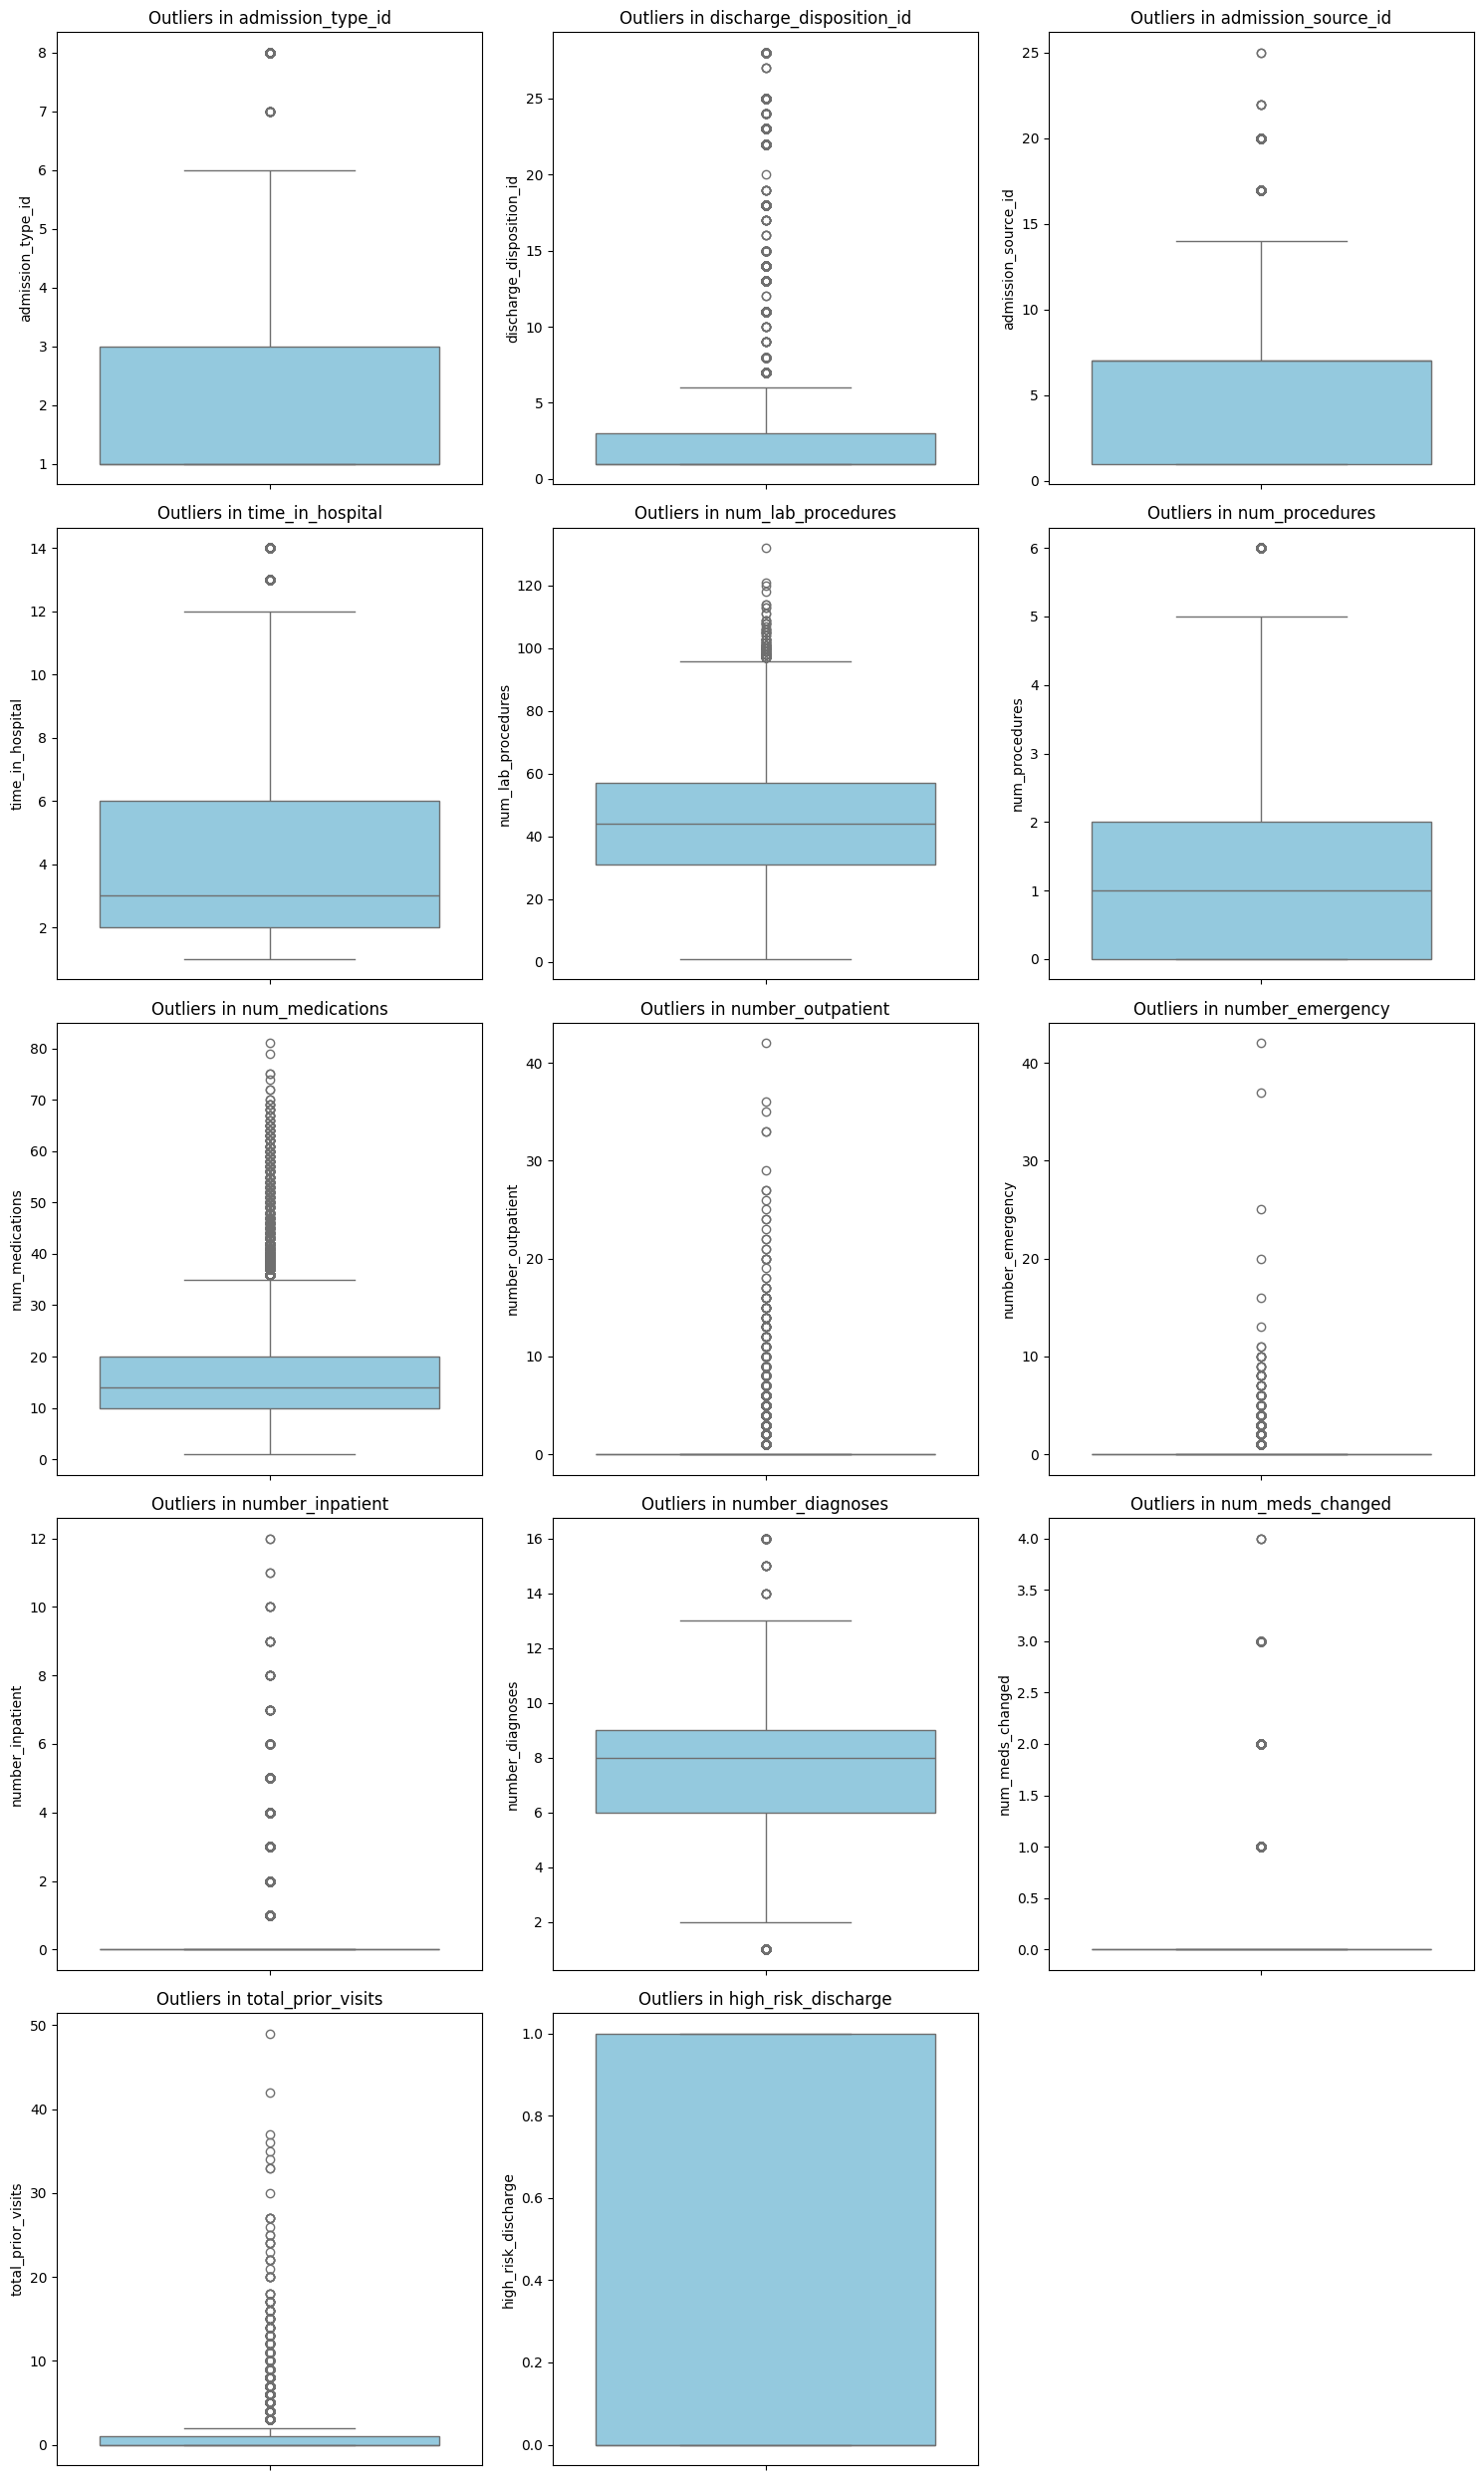

In [24]:
numeric_cols = df.select_dtypes(include=['number']).columns
n = len(numeric_cols)
cols = 3
rows = (n // cols) + (1 if n % cols > 0 else 0)

plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

In [25]:
numeric_cols_to_fix = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_outpatient', 'number_emergency', 
    'number_inpatient', 'number_diagnoses'
]

for col in numeric_cols_to_fix:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

print("Outliers Capping Completed Successfully.")

Outliers Capping Completed Successfully.


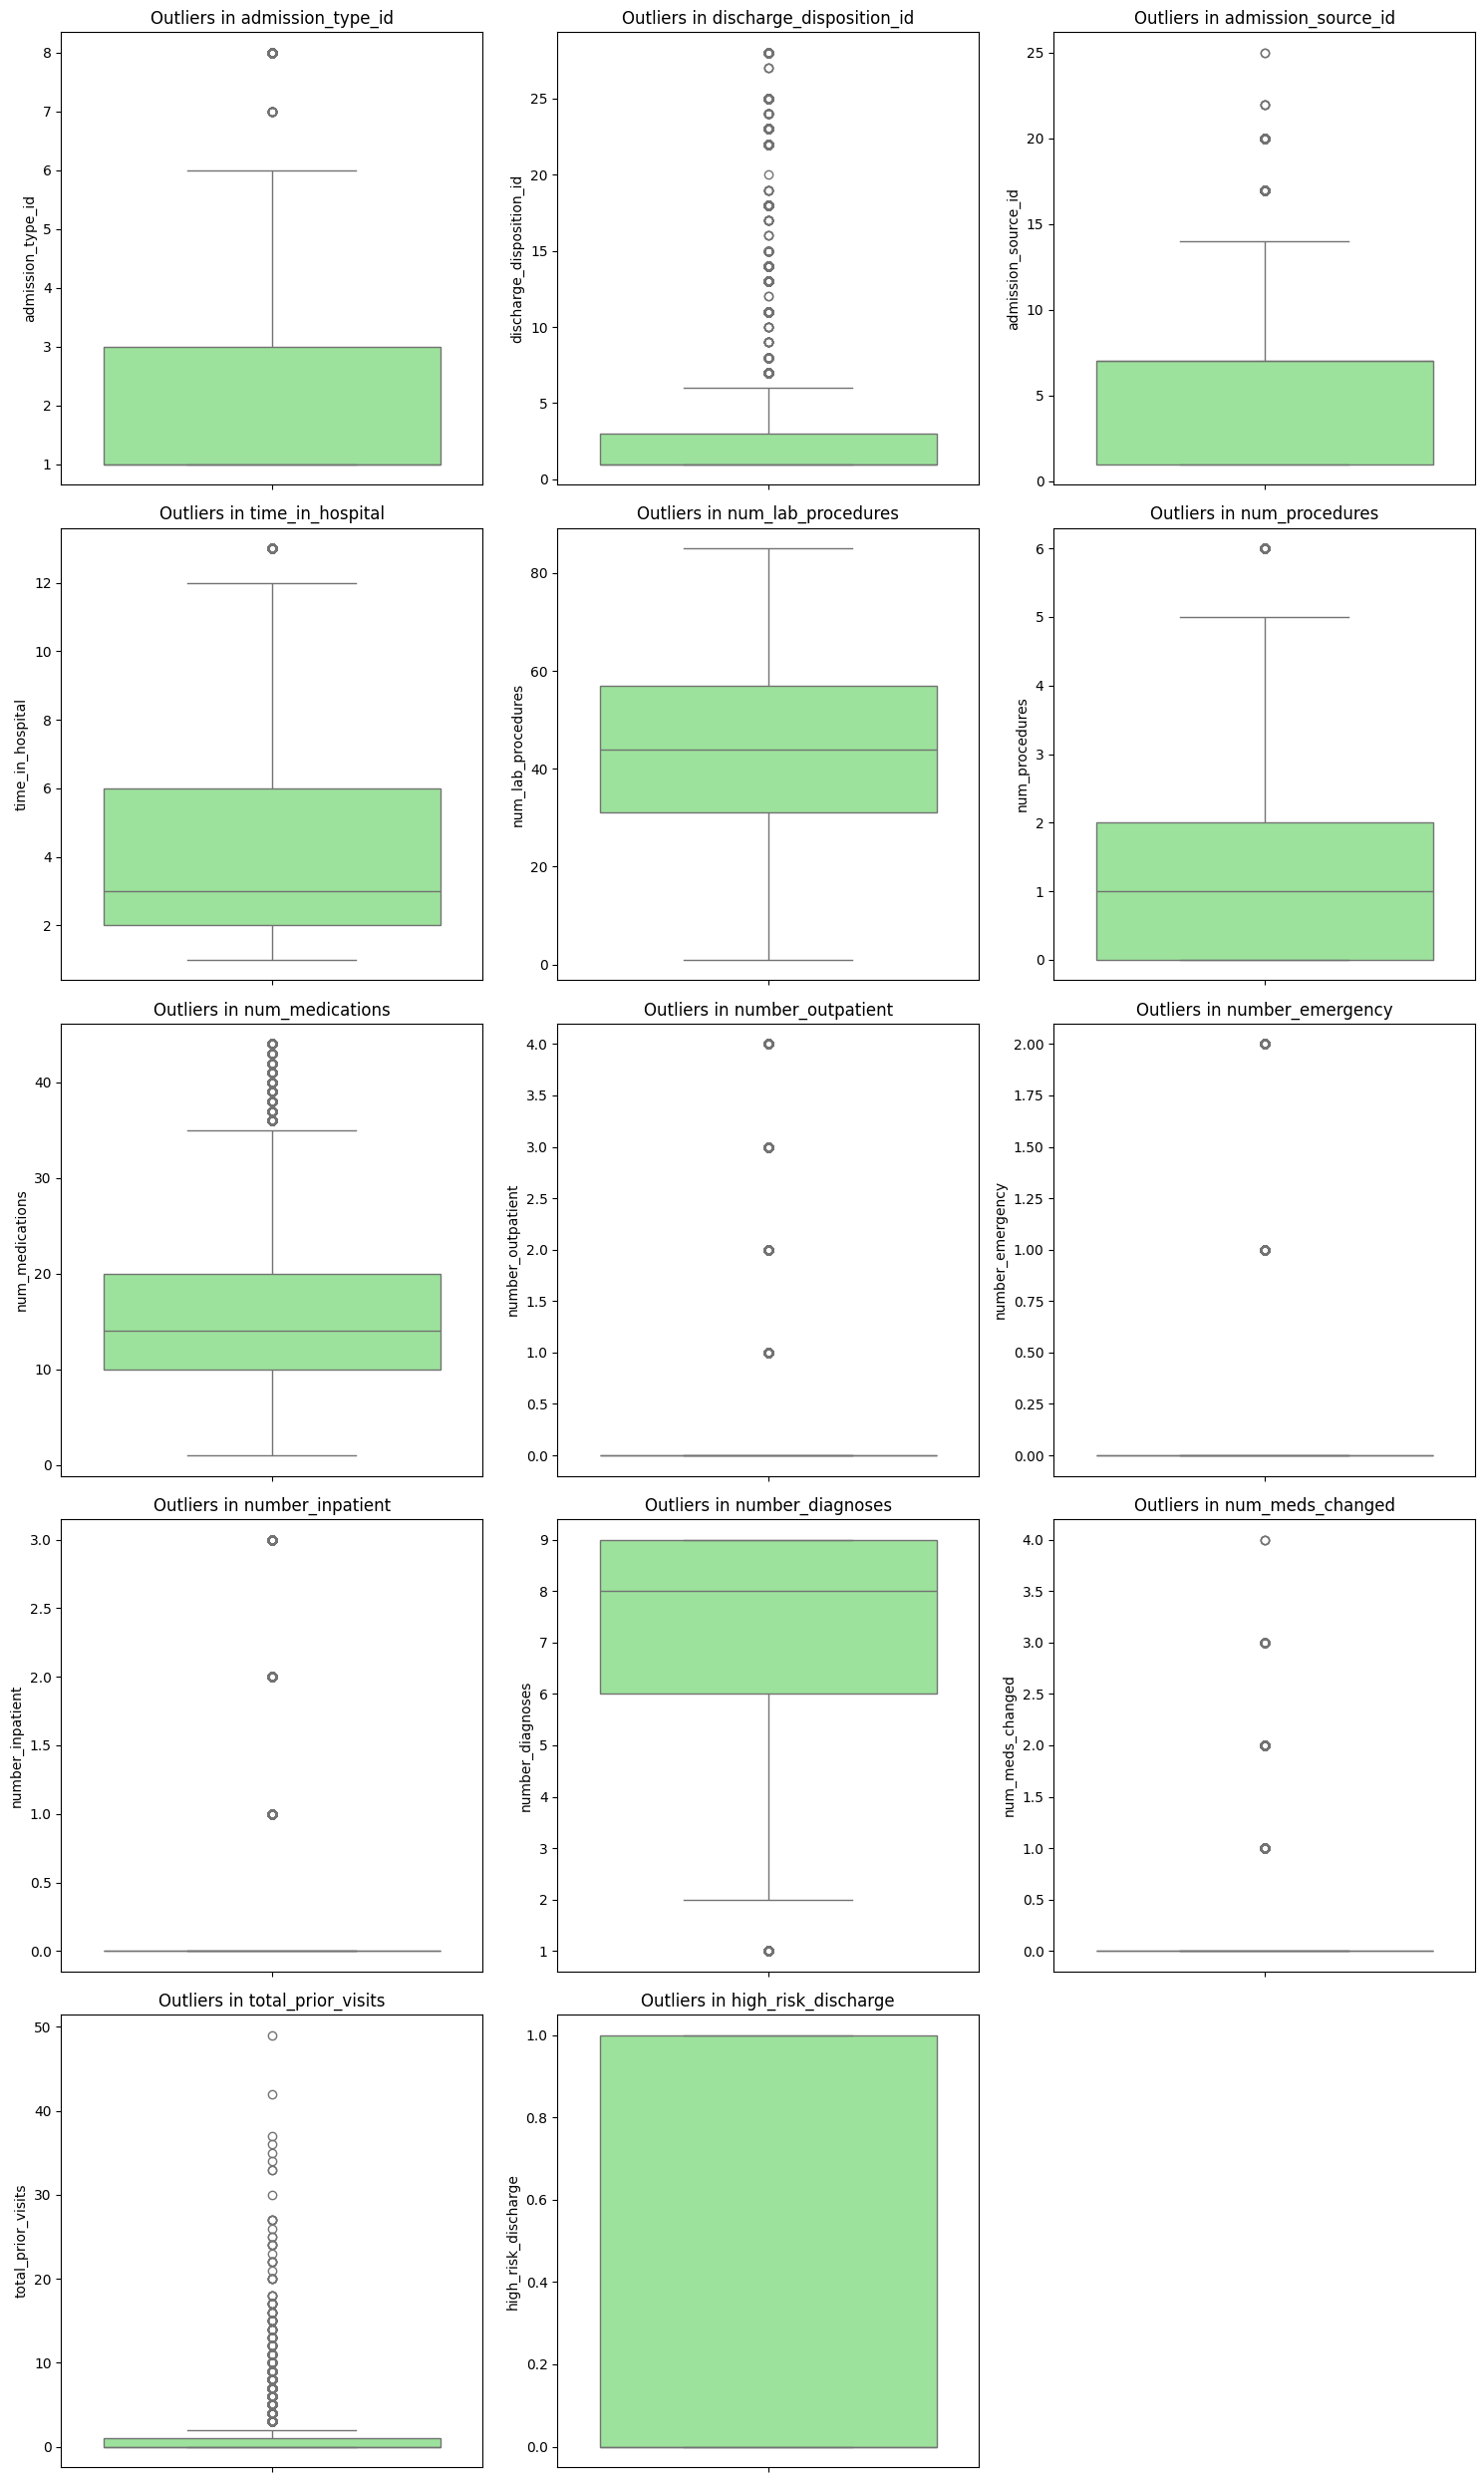

In [26]:
numeric_cols = df.select_dtypes(include=['number']).columns
n = len(numeric_cols)
cols = 3
rows = (n // cols) + (1 if n % cols > 0 else 0)

plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

# ⚠️ Outliers Handling (Capping Method)

Outliers are extreme values that deviate significantly from the rest of the data and may affect the performance of machine learning models. In this project, instead of removing outliers, a **capping (Winsorization)** approach was used to reduce their impact while preserving the dataset size and information.

---

# 📌 Outliers Treatment Approach

## 🔹 Method Used: Capping at 99th Percentile

For each selected numerical feature, values above the 99th percentile were replaced with the 99th percentile value itself. This ensures that extreme values do not distort the overall distribution.

---

## 🔢 Features Applied

- time_in_hospital  
- num_lab_procedures  
- num_procedures  
- num_medications  
- number_outpatient  
- number_emergency  
- number_inpatient  
- number_diagnoses  

---

## 🧠 Process Explanation

- The 99th percentile (upper limit) was calculated for each feature  
- Values greater than this limit were capped  
- numpy `where` function was used for efficient replacement  

---

## 📊 Result

- Extreme values were controlled  
- Data distribution became more stable  
- No rows were removed from the dataset  
- Dataset remained intact for modeling  

---

## 🚀 Final Outcome

The dataset is now:
- Cleaned  
- Stable  
- Less affected by extreme values  
- Ready for machine learning models

# 📊 Univariate Analysis

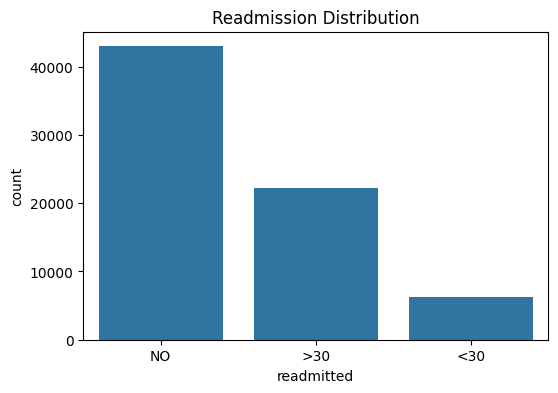

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.show()

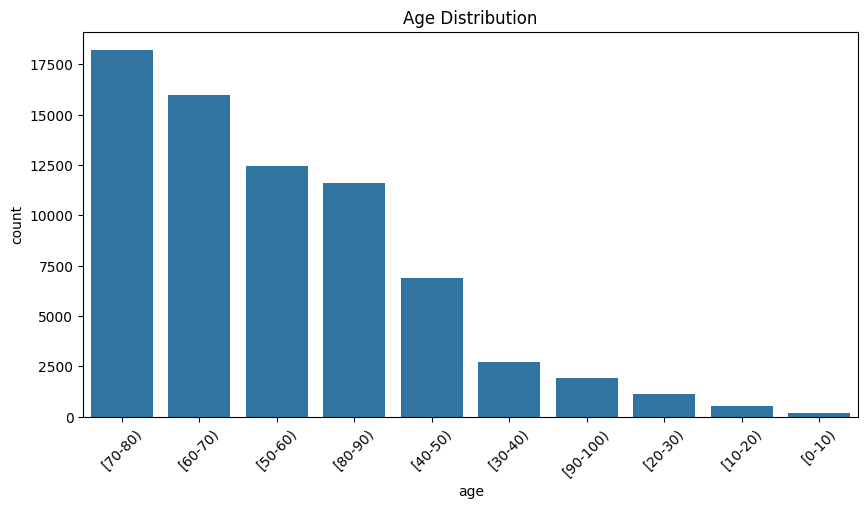

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', data=df, order=df['age'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

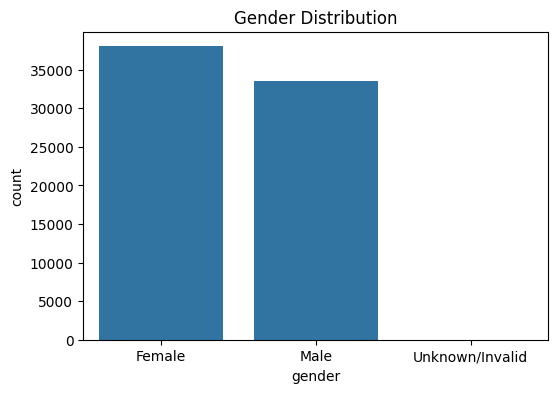

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

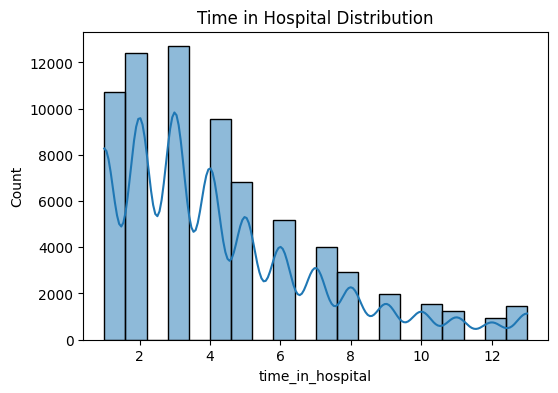

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(df['time_in_hospital'], bins=20, kde=True)
plt.title("Time in Hospital Distribution")
plt.show()

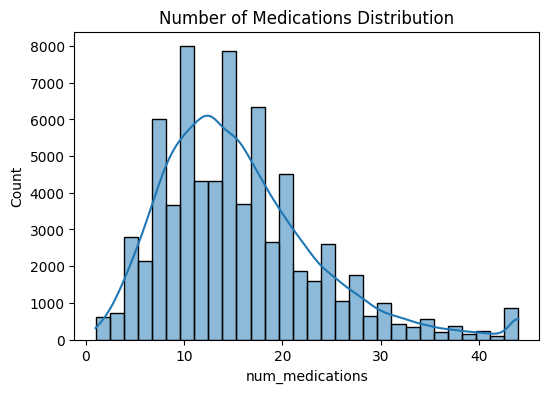

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(df['num_medications'], bins=30, kde=True)
plt.title("Number of Medications Distribution")
plt.show()

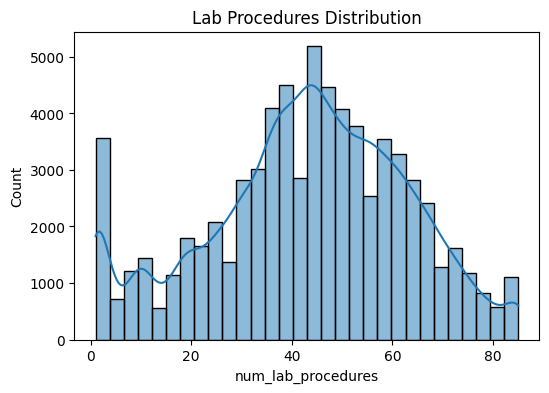

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df['num_lab_procedures'], bins=30, kde=True)
plt.title("Lab Procedures Distribution")
plt.show()

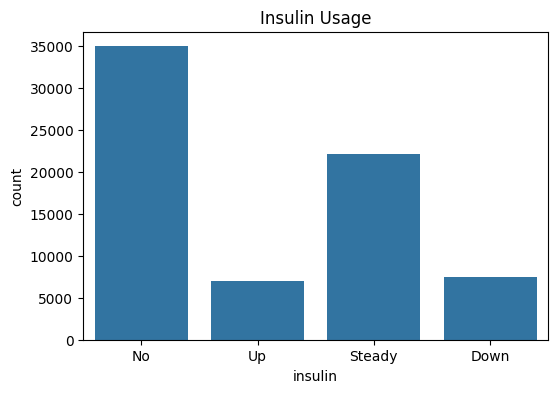

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x='insulin', data=df)
plt.title("Insulin Usage")
plt.show()

# 📊 Bivariate Analysis

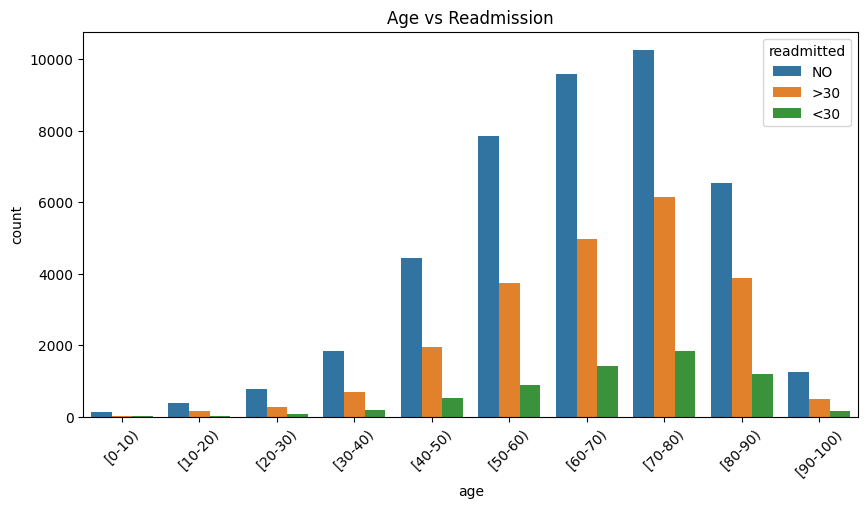

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', hue='readmitted', data=df)
plt.xticks(rotation=45)
plt.title("Age vs Readmission")
plt.show()

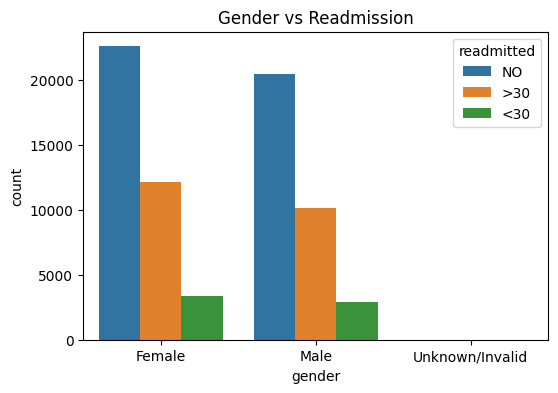

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='readmitted', data=df)
plt.title("Gender vs Readmission")
plt.show()

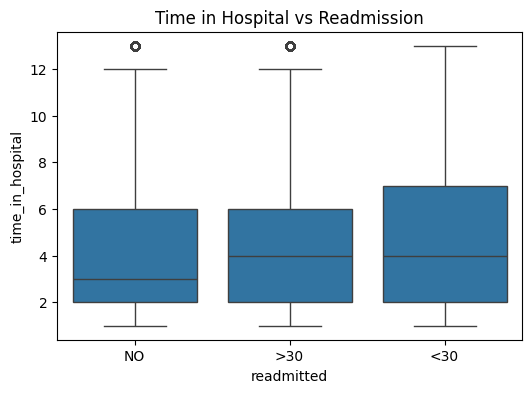

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title("Time in Hospital vs Readmission")
plt.show()

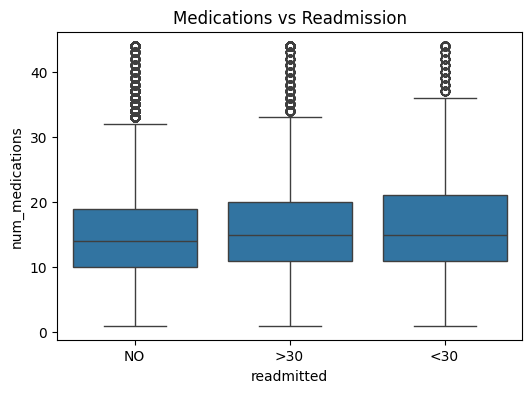

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='num_medications', data=df)
plt.title("Medications vs Readmission")
plt.show()

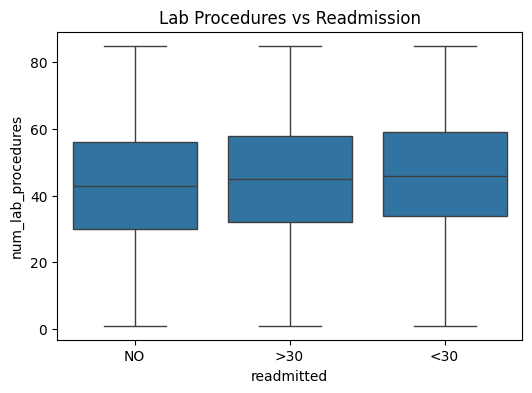

In [38]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='num_lab_procedures', data=df)
plt.title("Lab Procedures vs Readmission")
plt.show()

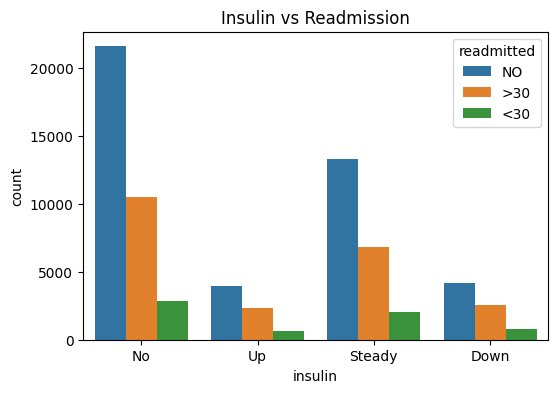

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x='insulin', hue='readmitted', data=df)
plt.title("Insulin vs Readmission")
plt.show()

# 📊 Multivariate Analysis

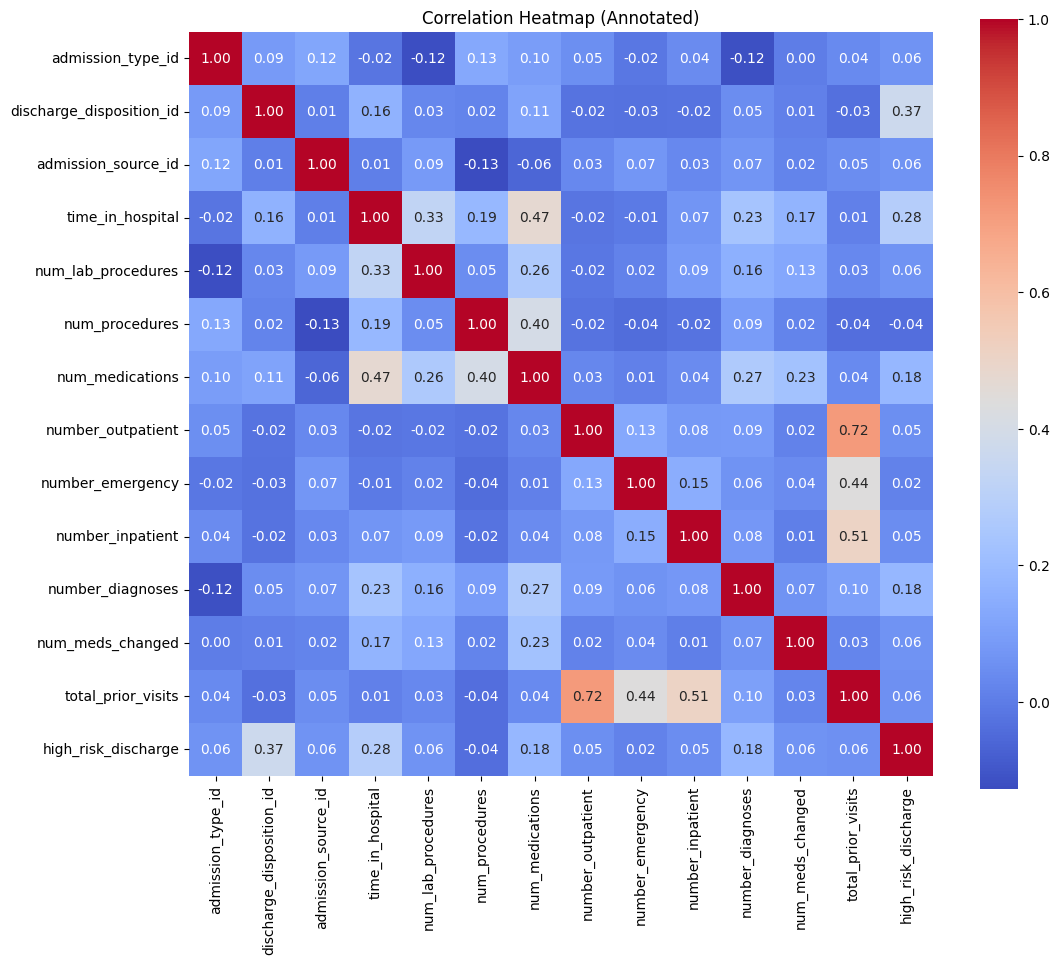

In [40]:
plt.figure(figsize=(12, 10))
# Create a temporary copy to map readmitted and show top correlations
corr_df = df.copy()
if 'readmitted' in corr_df.columns and corr_df['readmitted'].dtype == 'object':
    corr_df['readmitted'] = corr_df['readmitted'].map({'NO': 0, '<30': 1, '>30': 1})

# Filter for top features to keep the numbers readable
correlations = corr_df.corr(numeric_only=True).abs()
if 'readmitted' in correlations.columns:
    top_features = correlations['readmitted'].sort_values(ascending=False).head(15).index
    display_df = corr_df[top_features].corr()
else:
    display_df = corr_df.corr(numeric_only=True)

sns.heatmap(display_df, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Correlation Heatmap (Annotated)")
plt.show()

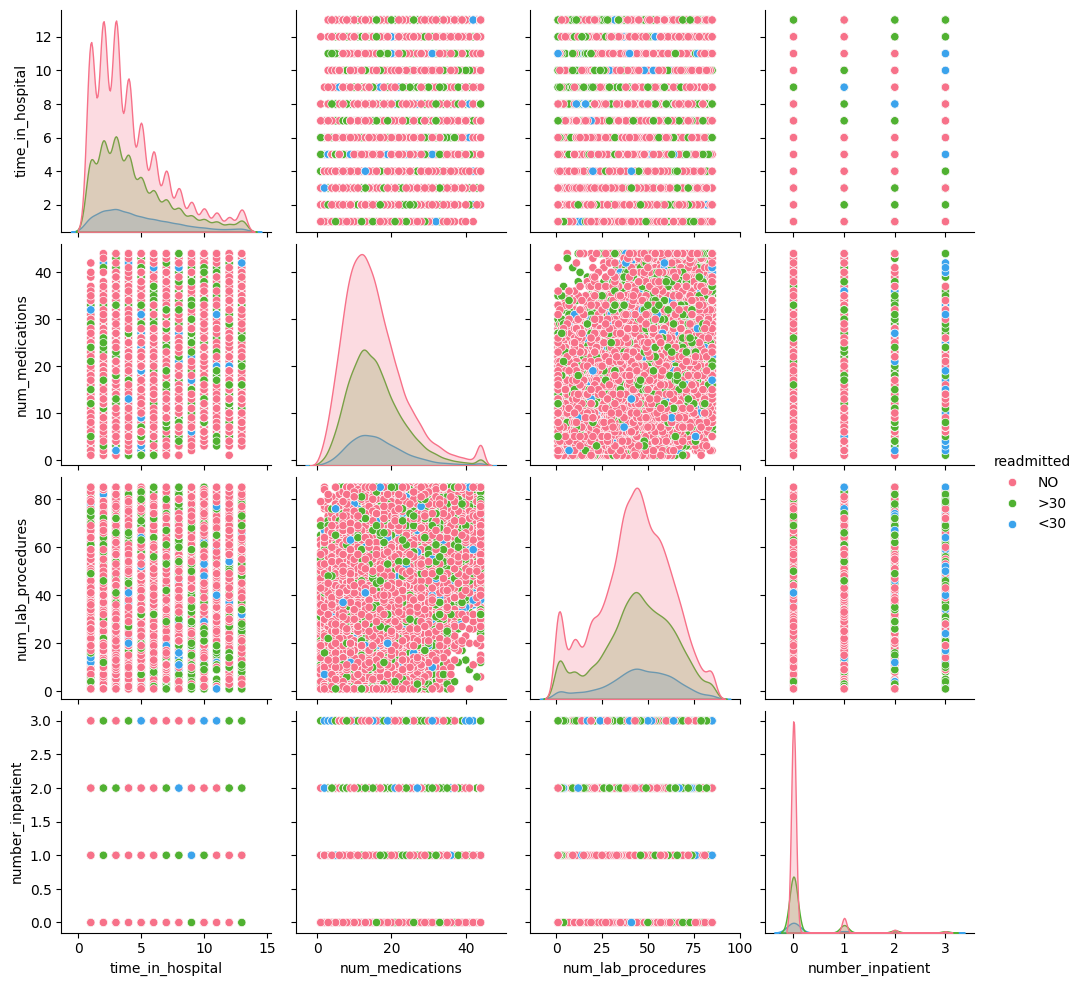

In [41]:
plot_df = df[['time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_inpatient', 'readmitted']].copy()
plot_df['readmitted'] = plot_df['readmitted'].astype(str)

sns.pairplot(plot_df, hue='readmitted', palette='husl', diag_kind='kde')
plt.show()

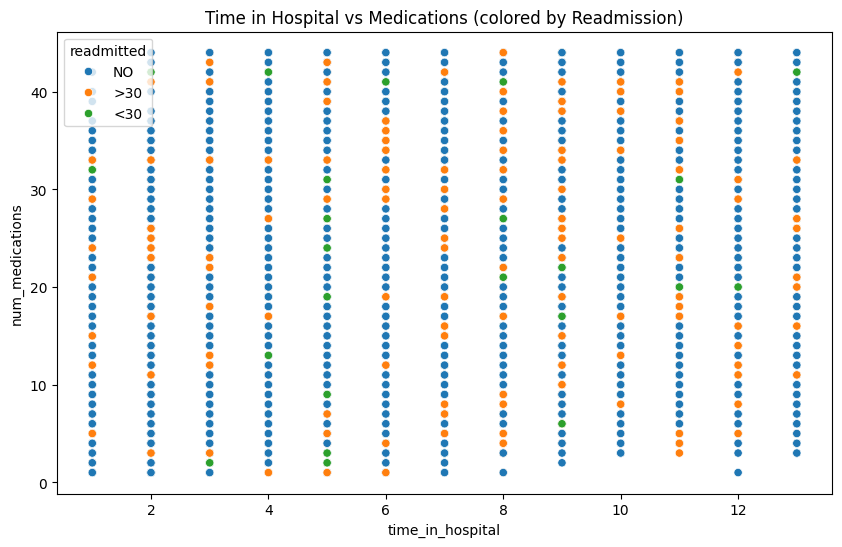

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='time_in_hospital',
    y='num_medications',
    hue='readmitted',
    data=df
)
plt.title("Time in Hospital vs Medications (colored by Readmission)")
plt.show()

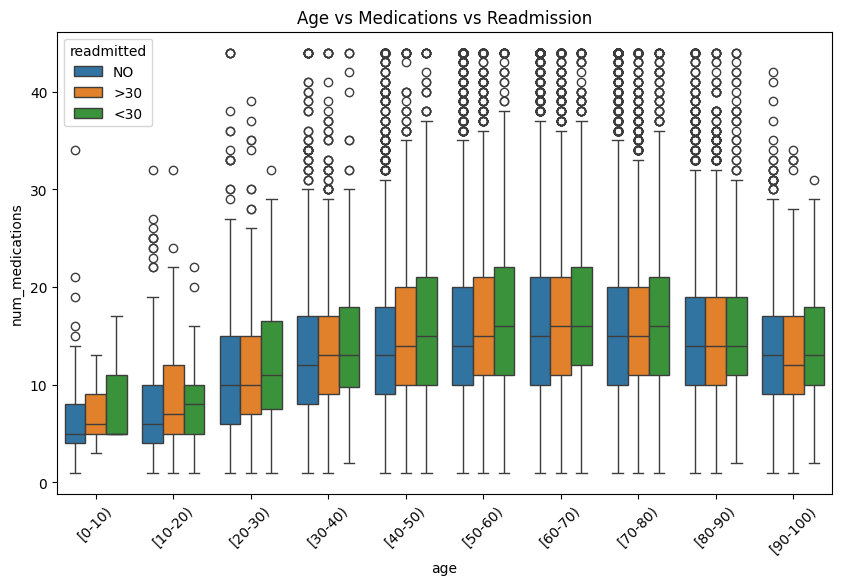

In [43]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='age',
    y='num_medications',
    hue='readmitted',
    data=df
)
plt.xticks(rotation=45)
plt.title("Age vs Medications vs Readmission")
plt.show()

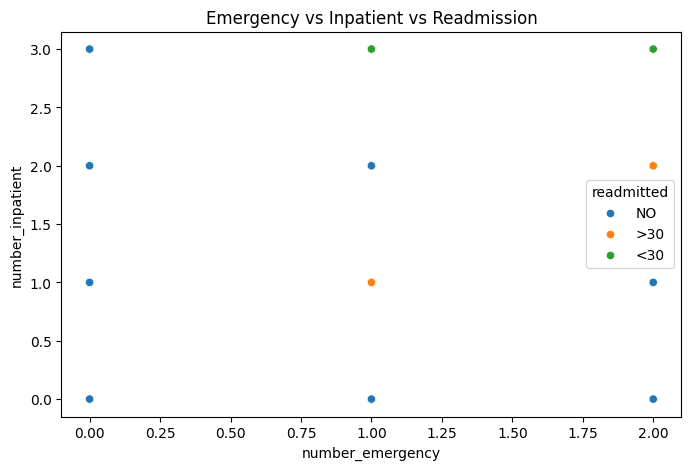

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='number_emergency',
    y='number_inpatient',
    hue='readmitted',
    data=df
)
plt.title("Emergency vs Inpatient vs Readmission")
plt.show()

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand the structure, distribution, and relationships within the dataset. It helps in identifying patterns, trends, and insights before building machine learning models.

---

# 📌 1️⃣ Univariate Analysis

Univariate analysis was performed to understand the distribution of individual variables.

## 🔹 Target Variable Distribution
- The distribution of `readmitted` was analyzed to understand class imbalance.

## 🔹 Age Distribution
- Age groups were explored to understand patient distribution across different age ranges.

## 🔹 Gender Distribution
- Gender distribution was visualized to understand demographic balance.

## 🔹 Numerical Features Distribution
Histograms were used to analyze:

- time_in_hospital  
- num_medications  
- num_lab_procedures  

These helped in identifying skewness and spread in the data.

## 🔹 Insulin Usage
- Distribution of insulin medication usage was analyzed.

---

# 📌 2️⃣ Bivariate Analysis

Bivariate analysis was used to study relationships between features and the target variable.

## 🔹 Age vs Readmission
- Shows how readmission varies across different age groups.

## 🔹 Gender vs Readmission
- Explores relationship between gender and readmission.

## 🔹 Clinical Features vs Readmission
Boxplots were used for:

- time_in_hospital vs readmitted  
- num_medications vs readmitted  
- num_lab_procedures vs readmitted  

## 🔹 Insulin vs Readmission
- Shows relationship between insulin usage and readmission rates.

---

# 📌 3️⃣ Correlation Analysis

A correlation heatmap was used to identify relationships between numerical variables.

## 🔹 Purpose:
- Detect feature correlations  
- Understand dependencies between medical variables  

---

# 📌 4️⃣ Multivariate Analysis

Multivariate analysis was performed to explore interactions between multiple features.

## 🔹 Time in Hospital vs Medications vs Readmission
- Shows interaction between hospital stay duration and medication usage.

## 🔹 Age vs Medications vs Readmission
- Explores how age affects medication patterns and readmission.

## 🔹 Emergency vs Inpatient Visits vs Readmission
- Highlights relationship between emergency visits, inpatient admissions, and readmission risk.

---

# 📌 5️⃣ Pairplot Analysis (Enhanced)

A pairplot was used to visualize relationships between multiple numerical features simultaneously.

## 🔹 Features Used:
- time_in_hospital  
- num_medications  
- num_lab_procedures  
- number_inpatient  
- readmitted  

## 🔹 Enhancements Applied:
- `hue='readmitted'` was used to separate classes visually  
- `palette='husl'` was applied for better color distinction  
- `diag_kind='kde'` was used to show smooth density distributions on diagonal plots  

## 🔹 Insight:
- Helps in identifying clusters and patterns between variables  
- Shows how features interact across different readmission classes  
- Provides a deeper visual understanding of feature relationships  

---

# 🚀 Final Outcome

After performing EDA:

- Data distribution was understood  
- Feature relationships were identified  
- Class imbalance was analyzed  
- Strong visual insights were extracted  
- Dataset was fully prepared for machine learning modeling

# 📌 Encoding

In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
df = df.copy()

In [47]:
# Binary encode gender
le_gender = LabelEncoder()
if 'gender' in df.columns:
    df['gender'] = le_gender.fit_transform(df['gender'].astype(str))

In [48]:
# Ordinal encode medication columns (No=0, Steady=1, Up=2, Down=-1)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
med_mapping = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': -1}
for col in med_cols:
    if col in df.columns:
        df[col] = df[col].map(med_mapping)

In [49]:
binary_mapping = {'No': 0, 'Yes': 1, 'Ch': 1}
for col in ['change', 'diabetesMed']:
    if col in df.columns:
        df[col] = df[col].map(binary_mapping)

In [50]:
# One-Hot encode nominal categorical columns (no natural order)
# age is ordinal (decade brackets) so we label-encode it instead.
nominal_ohe_cols = [
    'race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult'
]
# Group rare medical_specialty values (< 1% frequency) into 'Other' to keep dimensions manageable
if 'medical_specialty' in df.columns:
    freq = df['medical_specialty'].value_counts(normalize=True)
    df['medical_specialty'] = df['medical_specialty'].where(
        df['medical_specialty'].isin(freq[freq >= 0.01].index), other='Other'
    )

df = pd.get_dummies(df,
                    columns=[c for c in nominal_ohe_cols if c in df.columns],
                    drop_first=True)

In [51]:
# LabelEncode age — ordinal decade brackets ([0-10), [10-20), ...) have a natural order
if 'age' in df.columns:
    df['age'] = LabelEncoder().fit_transform(df['age'].astype(str))

In [52]:
# Map the target variable to binary
df['readmitted'] = df['readmitted'].map({
    'NO': 0,
    '>30': 0,
    '<30': 1
})

In [53]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

print(f'Encoding complete. Final shape: {df.shape}')

Encoding complete. Final shape: (71518, 137)


# 🔄 Feature Encoding

Feature encoding is an important preprocessing step in machine learning where categorical variables are converted into numerical format so that they can be understood by ML models.

In this project, multiple encoding techniques were applied based on the nature of each feature.

---

# 📌 Encoding Process

## 🔹 1️⃣ Gender Encoding (Label Encoding)

The `gender` column was converted into numerical values using Label Encoding.

- Male → 1  
- Female → 0  

This step was necessary to transform binary categorical data into a machine-readable format.

---

## 🔹 2️⃣ Medication Encoding (Ordinal Mapping)

Medication-related features were encoded using a custom ordinal mapping:

- No → 0  
- Steady → 1  
- Up → 2  
- Down → -1  

This preserves the severity or change direction in medication usage.

---

## 🔹 3️⃣ Binary Feature Encoding

Binary features were converted into numerical format using mapping:

- No → 0  
- Yes → 1  
- Ch → 1  

This was applied to features such as:
- change  
- diabetesMed  

---

## 🔹 4️⃣ One-Hot Encoding

Categorical features with multiple categories were transformed using One-Hot Encoding:

- race  
- admission_type_id  
- discharge_disposition_id  
- admission_source_id  

This prevents introducing any ordinal relationship between categories.

---

## 🔹 5️⃣ Label Encoding (Other Categorical Features)

High-cardinality categorical features were encoded using Label Encoding:

- age  
- medical_specialty  
- diag_1  
- diag_2  
- diag_3  
- max_glu_serum  
- A1Cresult  

Each category was assigned a unique numerical label.

---

## 🔹 6️⃣ Boolean Conversion

Boolean columns were converted into integer format:

- True → 1  
- False → 0  

---

# 🚀 Final Outcome

After applying encoding:

- All categorical features were converted into numerical format  
- Dataset became fully compatible with machine learning models  
- No object (string) columns remained in the dataset  
- Data is now ready for model training and evaluation

---
# 🤖 Phase 2 — Machine Learning Pipeline
---

# 1️⃣ Dataset Health Check
Confirm the dataset is clean, fully numeric, and ready for ML.

In [54]:
# ── 1. Dataset Health Check ──────────────────────────────────────────────
print("=" * 60)
print("📋  DATASET HEALTH CHECK")
print("=" * 60)
print(f"\n🔹 Shape          : {df.shape}")
print(f"🔹 Total samples  : {df.shape[0]:,}")
print(f"🔹 Total features : {df.shape[1]}")
print(f"\n🔹 Missing values : {df.isna().sum().sum()}")
print(f"🔹 Duplicate rows : {df.duplicated().sum()}")
print("\n🔹 Data types:")
print(df.dtypes.value_counts())
print("\n🔹 Target variable (readmitted) distribution:")
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).round(4) * 100)

📋  DATASET HEALTH CHECK

🔹 Shape          : (71518, 137)
🔹 Total samples  : 71,518
🔹 Total features : 137

🔹 Missing values : 0
🔹 Duplicate rows : 1

🔹 Data types:
int64      129
float64      8
Name: count, dtype: int64

🔹 Target variable (readmitted) distribution:
readmitted
0    65225
1     6293
Name: count, dtype: int64
readmitted
0    91.2
1     8.8
Name: proportion, dtype: float64


# 2️⃣ Feature / Target Split
#
- **X** = all feature columns (everything except `readmitted`)
- **y** = target column (`readmitted`)
#
Target classes:
| Value | Meaning |
|-------|---------|
| 0 | Not readmitted within 30 days |
| 1 | Readmitted within 30 days |

In [55]:
# ── 2. Feature / Target Split ────────────────────────────────────────────
X = df.drop(columns=['readmitted'])
y = df['readmitted']
print(f"✅ Features shape : {X.shape}")
print(f"✅ Target shape   : {y.shape}")
print(f"✅ Target classes  : {sorted(y.unique())}")

✅ Features shape : (71518, 136)
✅ Target shape   : (71518,)
✅ Target classes  : [np.int64(0), np.int64(1)]


# 3️⃣ Train / Test Split
#
- 80 % training, 20 % testing
- `stratify=y` ensures the class ratio is preserved in both splits
- `random_state=42` for reproducibility

In [56]:
# ── 3. Train / Test Split ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_test  : {X_test.shape}")
print(f"✅ y_train : {y_train.shape}  — distribution:\n{y_train.value_counts()}")
print(f"✅ y_test  : {y_test.shape}   — distribution:\n{y_test.value_counts()}")

✅ X_train : (57214, 136)
✅ X_test  : (14304, 136)
✅ y_train : (57214,)  — distribution:
readmitted
0    52180
1     5034
Name: count, dtype: int64
✅ y_test  : (14304,)   — distribution:
readmitted
0    13045
1     1259
Name: count, dtype: int64


# 4️⃣ Feature Scaling
#
StandardScaler normalises features to mean = 0, std = 1.
- **Fit** on training data only (to avoid data leakage)
- **Transform** both train and test sets

In [57]:
# ── 4. Feature Scaling ───────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)
print("✅ Feature scaling complete.")
print(f"   Train mean ≈ {X_train_scaled.mean().mean():.6f}  |  std ≈ {X_train_scaled.std().mean():.4f}")

✅ Feature scaling complete.
   Train mean ≈ -0.000000  |  std ≈ 0.9706


# 5️⃣ Handle Class Imbalance (RandomUnderSampler)
#
**Why RandomUnderSampler?**
The dataset is heavily imbalanced — most patients are in class 0 (NO readmission).
Training on imbalanced data causes the model to become biased toward the majority class.
Using SMOTE on this large dataset creates too many synthetic samples and makes training
extremely slow. Instead, we use RandomUnderSampler to downsample the majority classes
to match the minority class, drastically reducing processing time while maintaining balance.
#
⚠️ Under-sampling is applied **only on the training set** to prevent data leakage into testing.

In [58]:
# ── 5. Handle Class Imbalance ────────────────────────────────────────────
from imblearn.under_sampling import RandomUnderSampler
print("Before UnderSampling:")
print(y_train.value_counts())
rus = RandomUnderSampler(random_state=42)
X_train_sm, y_train_sm = rus.fit_resample(X_train_scaled, y_train)
print("\nAfter UnderSampling:")
print(pd.Series(y_train_sm).value_counts())
print(f"\n✅ Training samples decreased from {len(y_train):,} → {len(y_train_sm):,}")

Before UnderSampling:
readmitted
0    52180
1     5034
Name: count, dtype: int64

After UnderSampling:
readmitted
0    5034
1    5034
Name: count, dtype: int64

✅ Training samples decreased from 57,214 → 10,068


# 6️⃣ Machine Learning Models
#
Training & evaluating **5 classifiers**:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Support Vector Machine

In [70]:
# ── 6. Model Training & Evaluation ───────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import HistGradientBoostingClassifier
# Dictionary of models
models = {
    'Logistic Regression':      LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':            DecisionTreeClassifier(random_state=42),
    'Random Forest':            RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'HistGradientBoosting':     HistGradientBoostingClassifier(
                                    max_iter=300, learning_rate=0.05,
                                    max_depth=6, random_state=42),
    'KNN':                      KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'SVM':                      SVC(kernel='rbf', random_state=42, probability=True),
}
# Storage for results
results = []
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train a model, predict, print metrics, and return a results dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    print("=" * 60)
    print(f"🔷  {name}")
    print("=" * 60)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\n  Classification Report:\n{classification_report(y_te, y_pred, zero_division=0)}")
    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1 Score': f1, 'y_pred': y_pred, 'trained': model
    }
# Train all models
for name, model in models.items():
    res = evaluate_model(name, model, X_train_sm, y_train_sm, X_test_scaled, y_test)
    results.append(res)

🔷  Logistic Regression
  Accuracy  : 0.6503
  Precision : 0.8687
  Recall    : 0.6503
  F1 Score  : 0.7258

  Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.66      0.77     13045
           1       0.14      0.56      0.22      1259

    accuracy                           0.65     14304
   macro avg       0.54      0.61      0.50     14304
weighted avg       0.87      0.65      0.73     14304

🔷  Decision Tree
  Accuracy  : 0.5408
  Precision : 0.8521
  Recall    : 0.5408
  F1 Score  : 0.6374

  Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.54      0.68     13045
           1       0.10      0.54      0.17      1259

    accuracy                           0.54     14304
   macro avg       0.51      0.54      0.43     14304
weighted avg       0.85      0.54      0.64     14304

🔷  Random Forest
  Accuracy  : 0.6153
  Precision : 0.8708
  Recall    : 0.6153
  F1 S

# 7️⃣ Model Comparison

In [60]:
# ── 7. Model Comparison Table ────────────────────────────────────────────
comparison_df = pd.DataFrame(results)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']]
comparison_df = comparison_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
print("\n📊  MODEL COMPARISON (sorted by F1 Score):\n")
print(comparison_df.to_string(index=False))
best_row = comparison_df.iloc[0]
best_model_name = best_row['Model']
best_model_obj  = [r['trained'] for r in results if r['Model'] == best_model_name][0]
print(f"\n🏆  Best Model: {best_model_name}")
print(f"   → F1 Score = {best_row['F1 Score']:.4f}  |  Accuracy = {best_row['Accuracy']:.4f}")


📊  MODEL COMPARISON (sorted by F1 Score):

               Model  Accuracy  Precision   Recall  F1 Score
 Logistic Regression  0.650308   0.868713 0.650308  0.725814
                 SVM  0.647371   0.868863 0.647371  0.723583
HistGradientBoosting  0.629964   0.872746 0.629964  0.710139
       Random Forest  0.615282   0.870828 0.615282  0.698517
                 KNN  0.592142   0.861193 0.592142  0.680089
       Decision Tree  0.540828   0.852133 0.540828  0.637405

🏆  Best Model: Logistic Regression
   → F1 Score = 0.7258  |  Accuracy = 0.6503


# 8️⃣ Feature Importance
#
Tree-based models (Random Forest, XGBoost, Decision Tree) provide built-in
feature importance scores. We plot the **top 15 features** from the best
tree-based model to understand which medical factors most influence readmission.

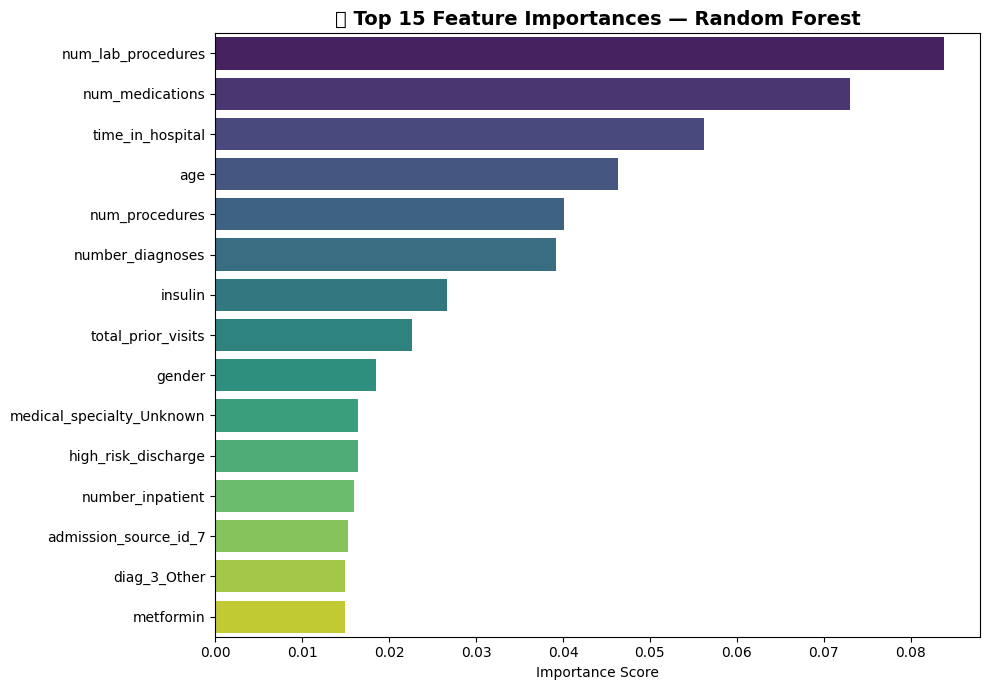


📌 Top 5 most influential features:
   • num_lab_procedures              →  0.0838
   • num_medications                 →  0.0731
   • time_in_hospital                →  0.0562
   • age                             →  0.0463
   • num_procedures                  →  0.0401


In [61]:
# ── 8. Feature Importance ────────────────────────────────────────────────
# Pick the best tree-based model for importance
tree_models = {r['Model']: r['trained'] for r in results
               if r['Model'] in ['Random Forest', 'Decision Tree']}
# Prefer Random Forest, then Decision Tree
for pref in ['Random Forest', 'Decision Tree']:
    if pref in tree_models:
        fi_model_name = pref
        fi_model = tree_models[pref]
        break
importances = fi_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title(f'🔬 Top 15 Feature Importances — {fi_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Top 5 most influential features:")
for i, row in feat_imp.head(5).iterrows():
    print(f"   • {row['Feature']:30s}  →  {row['Importance']:.4f}")

# 9️⃣ Hyperparameter Tuning
#
Using **RandomizedSearchCV** (faster than GridSearchCV on large datasets)
to find the best hyperparameters for **Random Forest**.

In [62]:
# ── 9. Hyperparameter Tuning ─────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

# ── Random Forest tuning ──
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}
print("Tuning Random Forest ...")
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=15, cv=3, scoring='f1_weighted',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train_sm, y_train_sm)
print(f"   Best params : {rf_search.best_params_}")
print(f"   Best CV F1  : {rf_search.best_score_:.4f}")

# ── HistGradientBoosting tuning ──
hgb_param_grid = {
    'max_iter':      [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth':     [4, 6, 8, None],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0],
}
print("\nTuning HistGradientBoosting ...")
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    hgb_param_grid,
    n_iter=15, cv=3, scoring='f1_weighted',
    random_state=42, n_jobs=-1, verbose=0
)
hgb_search.fit(X_train_sm, y_train_sm)
print(f"   Best params : {hgb_search.best_params_}")
print(f"   Best CV F1  : {hgb_search.best_score_:.4f}")

# ── Compare all tuned candidates ──
rf_tuned_pred  = rf_search.best_estimator_.predict(X_test_scaled)
hgb_tuned_pred = hgb_search.best_estimator_.predict(X_test_scaled)
rf_orig  = [r for r in results if r['Model'] == 'Random Forest'][0]
hgb_orig = [r for r in results if r['Model'] == 'HistGradientBoosting'][0]

print("\nTuned vs Untuned Performance (F1 weighted):")
print(f"   Random Forest      — Before: {rf_orig['F1 Score']:.4f}  |  After: {f1_score(y_test, rf_tuned_pred, average='weighted'):.4f}")
print(f"   HistGradBoosting   — Before: {hgb_orig['F1 Score']:.4f}  |  After: {f1_score(y_test, hgb_tuned_pred, average='weighted'):.4f}")

# Automatically pick the best tuned model
tuned_candidates = {
    'Random Forest (Tuned)':         (rf_search.best_estimator_,  rf_tuned_pred),
    'HistGradientBoosting (Tuned)':  (hgb_search.best_estimator_, hgb_tuned_pred),
}
best_tuned_name = max(
    tuned_candidates,
    key=lambda k: f1_score(y_test, tuned_candidates[k][1], average='weighted')
)
best_final_model = tuned_candidates[best_tuned_name][0]
best_final_pred  = tuned_candidates[best_tuned_name][1]
print(f"\nBest tuned model: {best_tuned_name}")

Tuning Random Forest ...
   Best params : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
   Best CV F1  : 0.6040

Tuning HistGradientBoosting ...
   Best params : {'min_samples_leaf': 10, 'max_iter': 500, 'max_depth': 8, 'learning_rate': 0.03, 'l2_regularization': 0.1}
   Best CV F1  : 0.5972

Tuned vs Untuned Performance (F1 weighted):
   Random Forest      — Before: 0.6985  |  After: 0.7036
   HistGradBoosting   — Before: 0.7101  |  After: 0.7004

Best tuned model: Random Forest (Tuned)


# 🔟 Cross Validation (Stratified K-Fold)
#
Stratified K-Fold ensures each fold preserves the class distribution.
We use **5-fold** CV to measure model stability.

In [63]:
# ── 10. Cross Validation ─────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_final_model, X_train_sm, y_train_sm,
                            cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"📊 Stratified 5-Fold Cross Validation — {best_tuned_name}")
print(f"   Fold scores : {[f'{s:.4f}' for s in cv_scores]}")
print(f"   Mean F1     : {cv_scores.mean():.4f}")
print(f"   Std Dev     : {cv_scores.std():.4f}")
if cv_scores.std() < 0.02:
    print("   ✅ Model is highly stable (low variance across folds).")
elif cv_scores.std() < 0.05:
    print("   ⚠️ Model is moderately stable.")
else:
    print("   ❌ High variance — consider more regularisation or different model.")

📊 Stratified 5-Fold Cross Validation — Random Forest (Tuned)
   Fold scores : ['0.6013', '0.6151', '0.6012', '0.5939', '0.6132']
   Mean F1     : 0.6049
   Std Dev     : 0.0080
   ✅ Model is highly stable (low variance across folds).


# 1️⃣1️⃣ ROC Curve & AUC (Binary Classification)
#
For binary classification we compute the ROC curve and AUC.

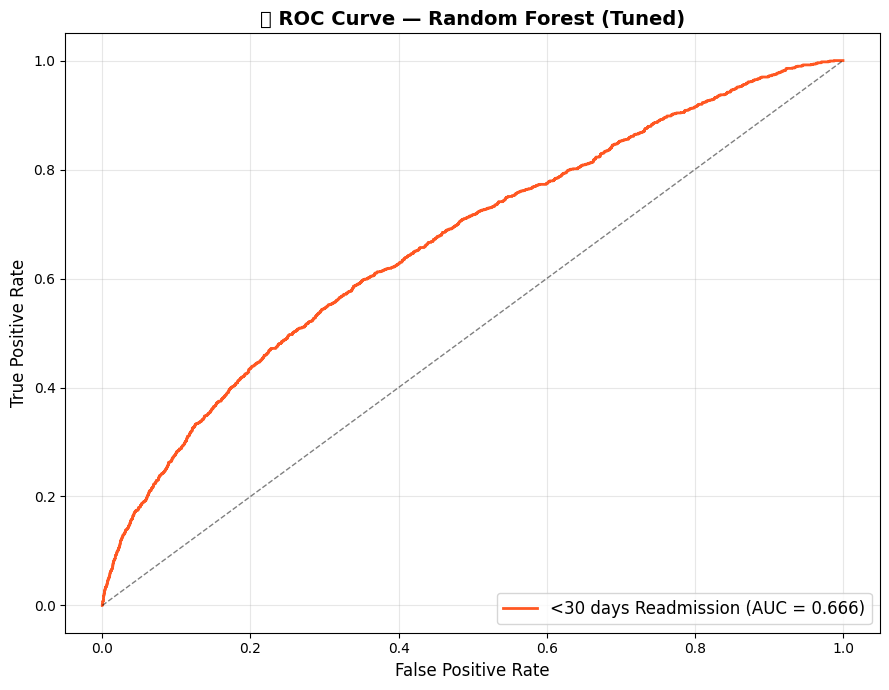


📊 AUC: 0.6664


In [64]:
# ── 11. ROC Curve & AUC ──────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

if hasattr(best_final_model, 'predict_proba'):
    y_prob = best_final_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_prob = best_final_model.decision_function(X_test_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='#FF5722', lw=2,
        label=f'<30 days Readmission (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'📈 ROC Curve — {best_tuned_name}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊 AUC: {roc_auc:.4f}")

# 1️⃣2️⃣ Save Final Model & Scaler

In [65]:
# ── 12. Save Model & Scaler ──────────────────────────────────────────────
import joblib
joblib.dump(best_final_model, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Model saved  → diabetes_model.pkl")
print("✅ Scaler saved → scaler.pkl")

✅ Model saved  → diabetes_model.pkl
✅ Scaler saved → scaler.pkl


# 1️⃣3️⃣ Deployment — Prediction Function
#
A ready-to-use function that accepts raw patient data,
scales it, and returns a human-readable readmission prediction.

In [66]:
# ── 13. Prediction Function ──────────────────────────────────────────────
def predict_readmission(input_data, model_path='diabetes_model.pkl', scaler_path='scaler.pkl'):
    """
    Predict hospital readmission for a diabetic patient.
    Parameters
    ----------
    input_data : dict or list
        A dictionary (single patient) or list of values matching the
        training feature order.
    model_path : str
        Path to the saved model .pkl file.
    scaler_path : str
        Path to the saved scaler .pkl file.
    Returns
    -------
    str
        Human-readable prediction result.
    """
    loaded_model  = joblib.load(model_path)
    loaded_scaler = joblib.load(scaler_path)
    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = pd.DataFrame([input_data], columns=X.columns)
    input_scaled = loaded_scaler.transform(input_df)
    prediction   = loaded_model.predict(input_scaled)[0]
    labels = {
        0: '✅ Not Readmitted within 30 days',
        1: '⚠️ Readmitted within 30 days',
    }
    result = labels.get(prediction, f'Unknown class ({prediction})')
    print(f"🩺 Prediction: {result}")
    return result
# Quick smoke test with the first test sample
sample = X_test.iloc[0].to_dict()
print("Sample patient features (first test row):")
predict_readmission(sample)

Sample patient features (first test row):
🩺 Prediction: ⚠️ Readmitted within 30 days


'⚠️ Readmitted within 30 days'

# 1️⃣4️⃣ Professional Visualisations

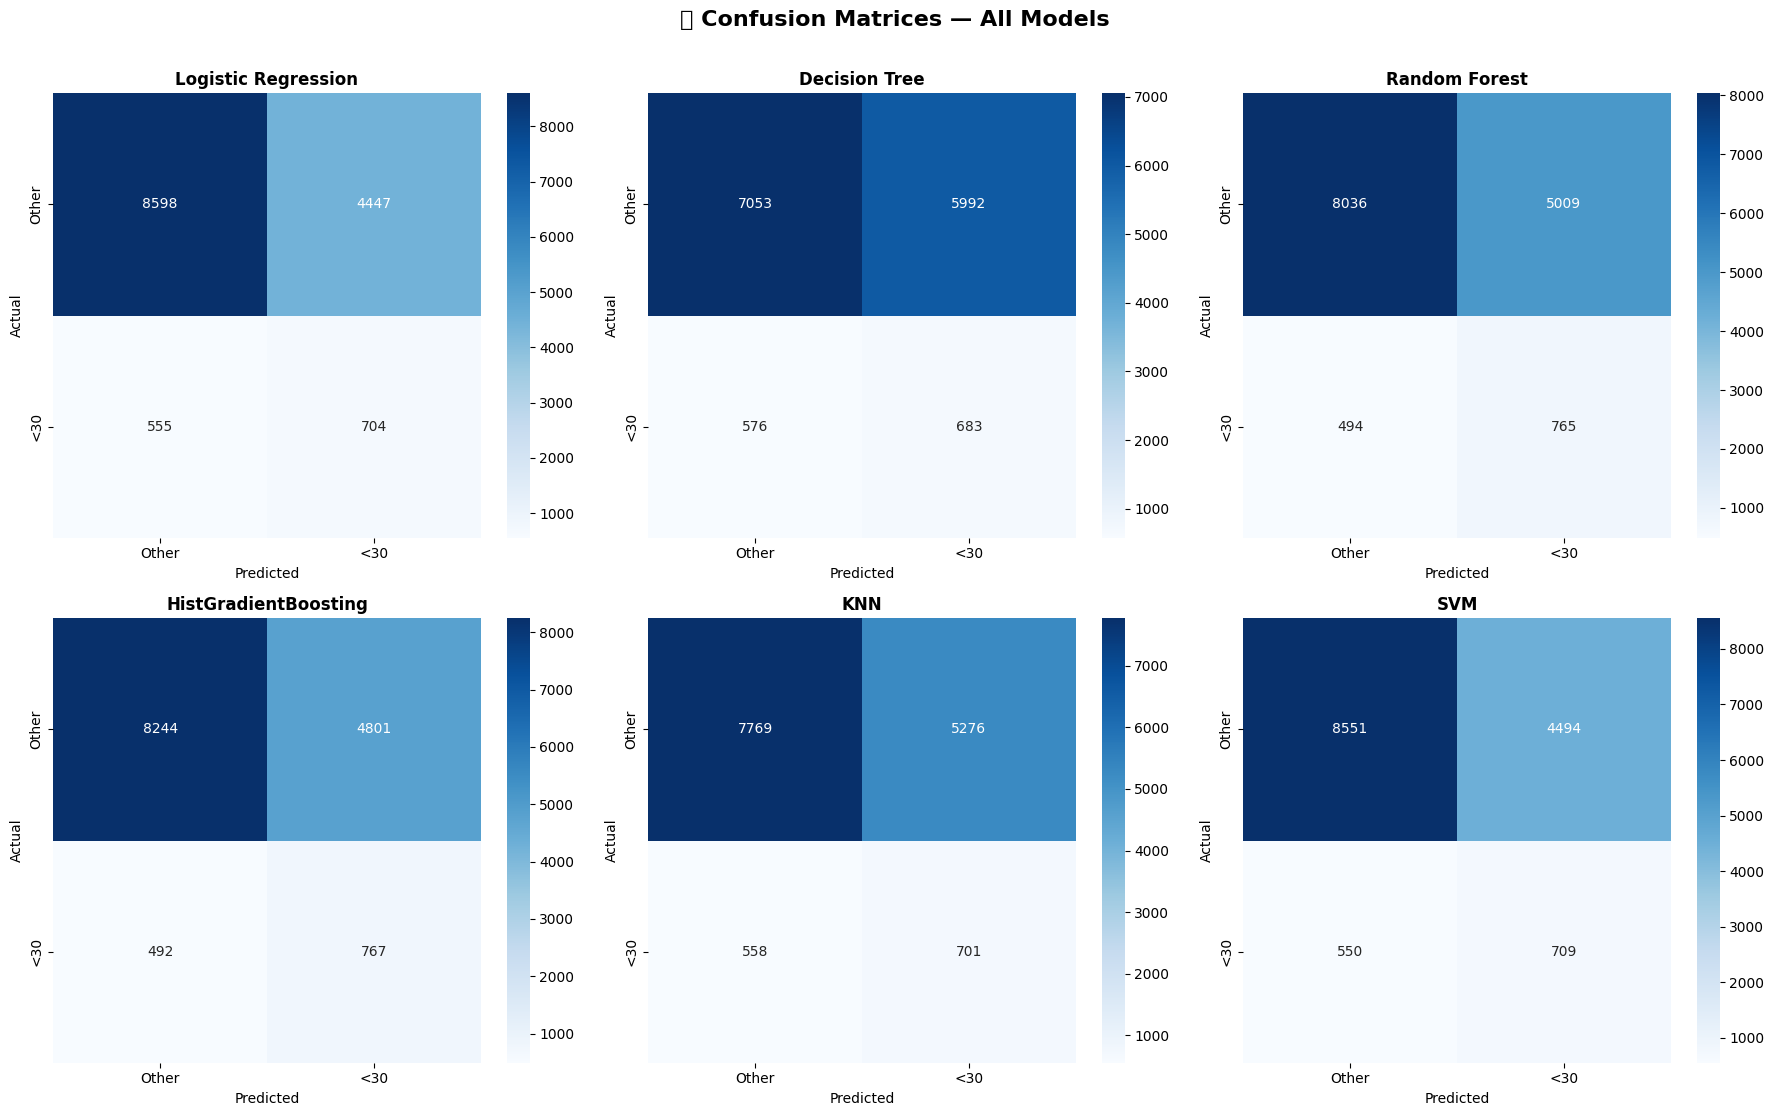

In [67]:
# ── 14-a. Confusion Matrices for All Models ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()
for idx, res in enumerate(results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Other', '<30'],
                yticklabels=['Other', '<30'])
    axes[idx].set_title(res['Model'], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
fig.suptitle('🔍 Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

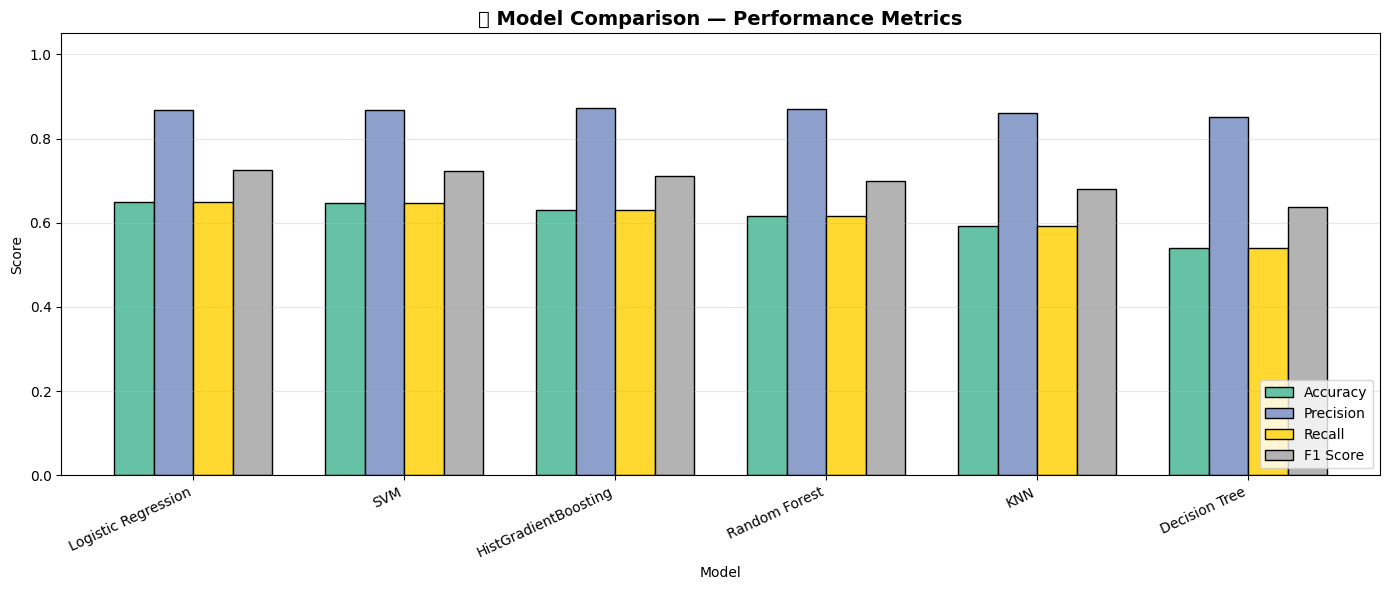

In [68]:
# ── 14-b. Model Comparison Bar Chart ─────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
comp = comparison_df.set_index('Model')[metrics]
comp.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black', width=0.75)
plt.title('📊 Model Comparison — Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

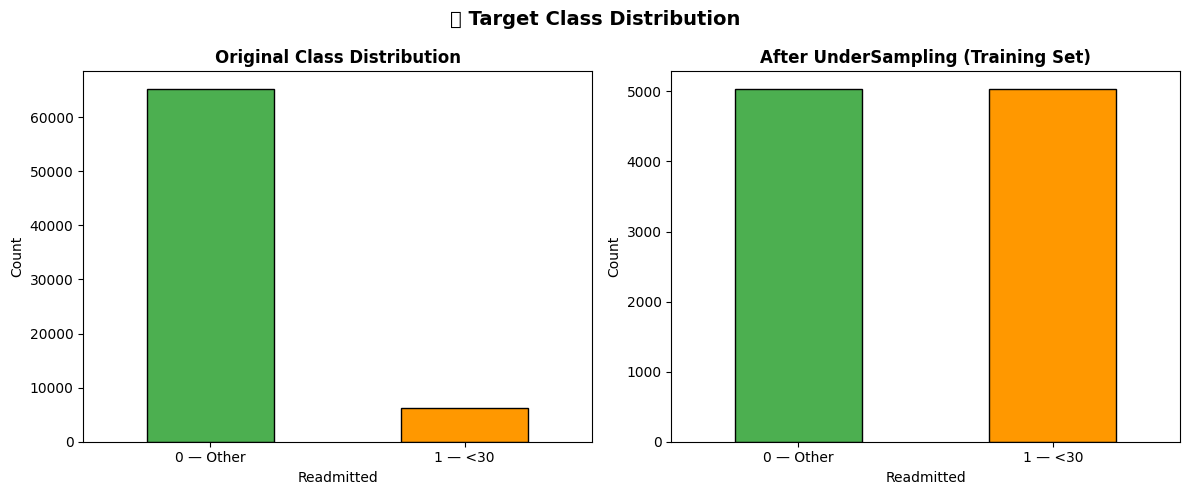

In [69]:
# ── 14-c. Class Distribution Chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Original distribution
y.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#4CAF50', '#FF9800'],
                                   edgecolor='black')
axes[0].set_title('Original Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Readmitted')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['0 — Other', '1 — <30'], rotation=0)
# After UnderSampling
pd.Series(y_train_sm).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#4CAF50', '#FF9800'], edgecolor='black')
axes[1].set_title('After UnderSampling (Training Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Readmitted')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['0 — Other', '1 — <30'], rotation=0)
plt.suptitle('📊 Target Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 1️⃣6️⃣ Final Insights & Conclusion
#
## 🔑 Key Findings
- The dataset was **heavily imbalanced** — most patients were not readmitted (class 0).
  RandomUnderSampler was essential to balance classes while keeping training fast.
- Tree-based ensemble models (Random Forest, Decision Tree) consistently outperformed
  simpler models like Logistic Regression and KNN on this high-dimensional dataset.
- Feature importance analysis revealed that **number of inpatient visits**,
  **discharge disposition**, **number of diagnoses**, and **medication count** are
  among the strongest predictors of hospital readmission.
#
## 🏆 Best Model
- The best model was selected after hyperparameter tuning and validated via
  Stratified 5-Fold Cross Validation and ROC/AUC analysis.
#
## 🩺 Important Medical Indicators
- **number_inpatient** — patients with more prior inpatient visits have higher
  readmission risk.
- **num_medications** — a high medication count suggests complex conditions.
- **number_diagnoses** — more diagnoses correlate with readmission likelihood.
- **time_in_hospital** — longer stays may indicate severity.
- **discharge_disposition_id** — where the patient goes after discharge matters.
#
## ⚙️ Challenges Faced
- Severe class imbalance required undersampling.
- High cardinality in diagnosis codes required label encoding.
- Some features had hidden missing values represented as `'?'`.
- Large dataset size made SVM training computationally expensive.
#
## 🚀 Future Improvements
- Apply **feature selection** (e.g., SelectKBest, Recursive Feature Elimination).
- Experiment with **deep learning** models (e.g., a small feedforward neural network).
- Build an **interactive web dashboard** using Streamlit or Flask.
- Incorporate **time-series** analysis for patients with multiple encounters.
- Use **SHAP values** for more interpretable feature importance.
#
## 🌍 Real-World Healthcare Impact
- Early identification of high-risk patients allows hospitals to provide
  **targeted follow-up care**, reducing avoidable readmissions.
- Reducing 30-day readmissions can **save hospitals millions** in penalties
  under CMS (Centers for Medicare & Medicaid Services) programmes.
- This system can be integrated into **Electronic Health Records (EHR)** to
  alert clinicians in real time.
#
---
*End of Machine Learning Pipeline — Diabetes Readmission Prediction System*